# Running a PtychoBench Benchmark

## Importing the core simulation components

In this cell, we import the main building blocks of the ptychography simulation framework:

- `SimulationGrid`: Defines the simulation domain (probe divergence, resolution, propagation distance, etc.). For more details see [simulation grid guide](docs/simulation_grid.md).

- `Apoferritin`: A biological sample object that defines how the samples refractive index varies in space. For more samples see [samples guide](docs/samples_guide.md).

- Operators (`ParaxialOperator`, `FeitFleckOperator`, `LinDudaOperator`):
  These implement different propagation models for the wavefield through the sample. Each corresponds to a different approximation. For more details see [Physics Simulation Explanation](docs/physics_simulation.md).

- `run_benchmark`: A utility function that runs the full simulation, computes errors of each propagation operator. For more details on results see [benchmarking guide](docs/benchmarking_guide.md).

Together, these components let us:
1. Define a simulation grid
2. Choose a physical sample
3. Select a propagation model(s)
4. Run and compare simulations

Before editing this notebook please ensure you create a new branch in your local git repository. This will allow you to make changes without affecting the main branch. You can create a new branch using the following command:

```bash
git checkout -b my-new-branch
```

In [67]:
from ptychobench.grid import SimulationGrid  # Simulation Sandbox
from ptychobench.samples import (
    StraightWaveguides,
)
from ptychobench.operators import (
    ParaxialOperator,
    FeitFleckOperator,
    LinDudaOperator,
    YevickThomsonOperator,
)  # Import the Operators
from ptychobench.benchmark import run_benchmark  # The Physics Engine

### Define the simulation grid and sample

We first create the simulation grid and choose a sample to propagate light through.

 - `SimulationGrid(divergence_angle=20)` sets up the physical domain and initial beam.
 The divergence angle controls how quickly the beam spreads as it propagates, with larger angles producing a more rapidly expanding wavefront.


 - `Apoferritin(modulus=0.8)` defines the sample we will simulate.
 The modulus parameter controls the strength of the refractive index perturbation.
 You can think of the modulus as the maximum contrast or scattering strength of the sample:
    - A larger modulus means the sample interacts more strongly with the wave, producing larger amplitude and phase changes.
    - A smaller modulus corresponds to a weaker, more weakly scattering object.

We can pass a list of operators to benchmark so we square brackets `[ParaxialOperator, FeitFleckOperator, LinDudaOperator]`
Alternatively, we can pass a single operator to benchmark, e.g. `ParaxialOperator`.

In [68]:
# 1. Setup Grid
backend = "numpy"  # Choose the backend for the simulation
grid = SimulationGrid(
    divergence_angle=4.0,  # Divergence angle of the initial Gaussian beam
    lam=0.00197,  # Wavelength of electrons in nm (corresponding to ~300 keV)
    L=12.8,  # nm Total transverse width of the simulation domain
    z_prop=0.5,  # nm Total propagation distance
    N=1000,  # Number of transverse pixels
    Nz=100,  # Number of longitudinal steps (z-steps)
    probe_width=4.0,  # Width of the initial Gaussian beam
    backend=backend,  # Backend for the simulation
)

# 2. Setup Sample
sample = StraightWaveguides(num_cores=8, core_width=0.5)

# 3. Operators to Benchmark
operators = [
    ParaxialOperator,
    FeitFleckOperator,
    LinDudaOperator,
    YevickThomsonOperator,
]

### Visualising the sample

```python
sample.plot(grid)
````

Displays the sample over $(x, z)$, showing its **modulus (scattering strength)** and **phase (wavefront shift)**.

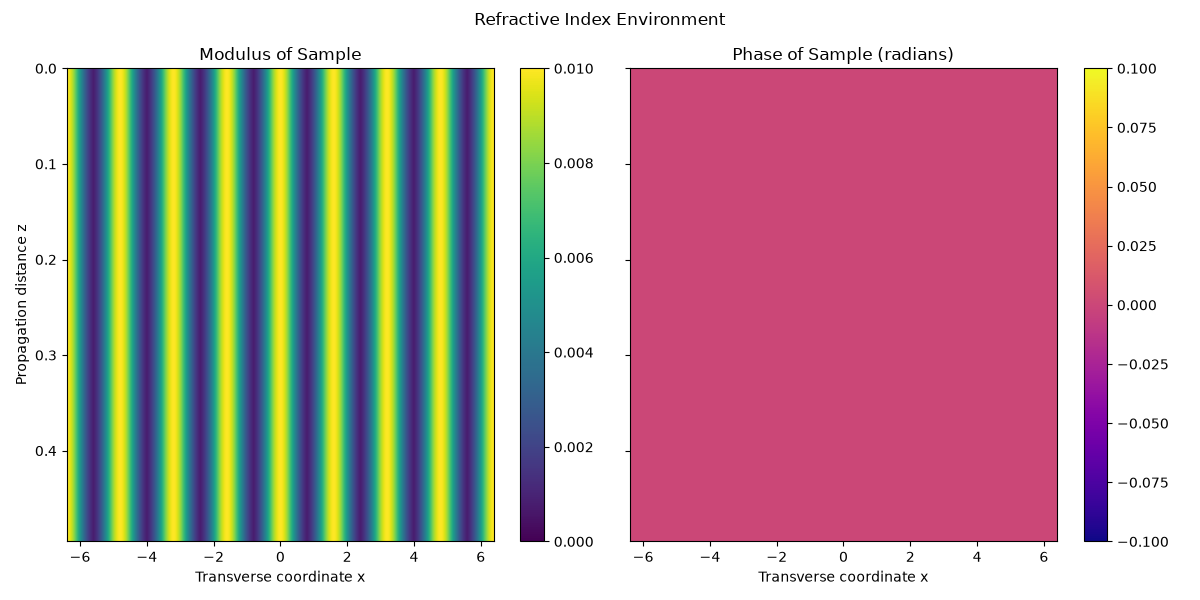

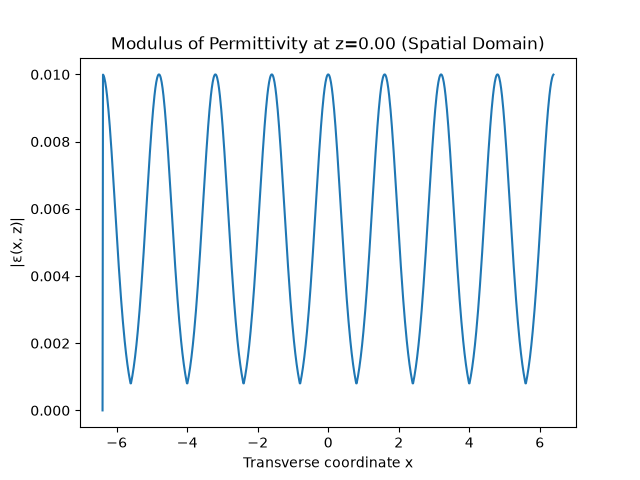

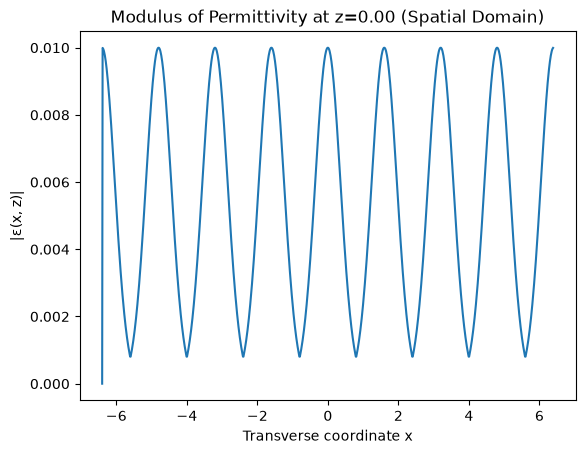

In [69]:
# # 4. Plot the sample to see it's structure
sample.plot(grid)

# Plot cross-section of the sample at z=0.0 in the Fourier domain
sample.plot_cross_section_modulus(grid)

### Run the benchmark and visualise the results

The benchmark propagates the wave through the sample using each operator and compare their accuracy. 

The generated plots summarise the results.

Comment out the `result.generate_report()` line to avoid generating saving results every time you run the benchmark.
For example,
```python
result = run_benchmark(grid, sample, operators)
# result.generate_report() # Uncomment to generate plots and save results
result.print_summary() # Print a formatted summary to your console
```

In [70]:
# 5. Run Benchmark
result = run_benchmark(grid, sample, operators, integrator="krylov")

# # 6. Generate Plots and Save Parameters
# result.generate_report()

# 7. Print a formatted summary to your console
result.print_summary()


--- Benchmark Summary: StraightWaveguides ---
Parameters:
  modulus     : 0.01
  phase       : 0.0
  num_cores   : 8
  core_width  : 0.5

 Wavefield Errors (RMSE relative to ExactOperator):
  Lin/Duda            : 1.315827e-07
  Yevick/Thomson      : 1.839103e-07
  Feit/Fleck          : 4.095356e-05
  Paraxial            : 4.394566e-03
---------------------------------------------

Detector Intensity Errors (RMSE relative to ExactOperator):
  Lin/Duda            : 3.004184e-04
  Yevick/Thomson      : 4.249972e-04
  Feit/Fleck          : 4.359298e-02
  Paraxial            : 4.537569e+01
---------------------------------------------

Detector Intensity Errors (Max Absolute Error relative to ExactOperator):
  Lin/Duda            : 4.345783e-03
  Yevick/Thomson      : 5.989588e-03
  Feit/Fleck          : 5.961860e-01
  Paraxial            : 5.847648e+02
---------------------------------------------


## Plot Wavefield Propagation Through the Sample

Plots two images showing the evolution of the wavefields phase and amplitude through the sample.

(<Figure size 3000x600 with 6 Axes>, <Figure size 3000x600 with 6 Axes>)

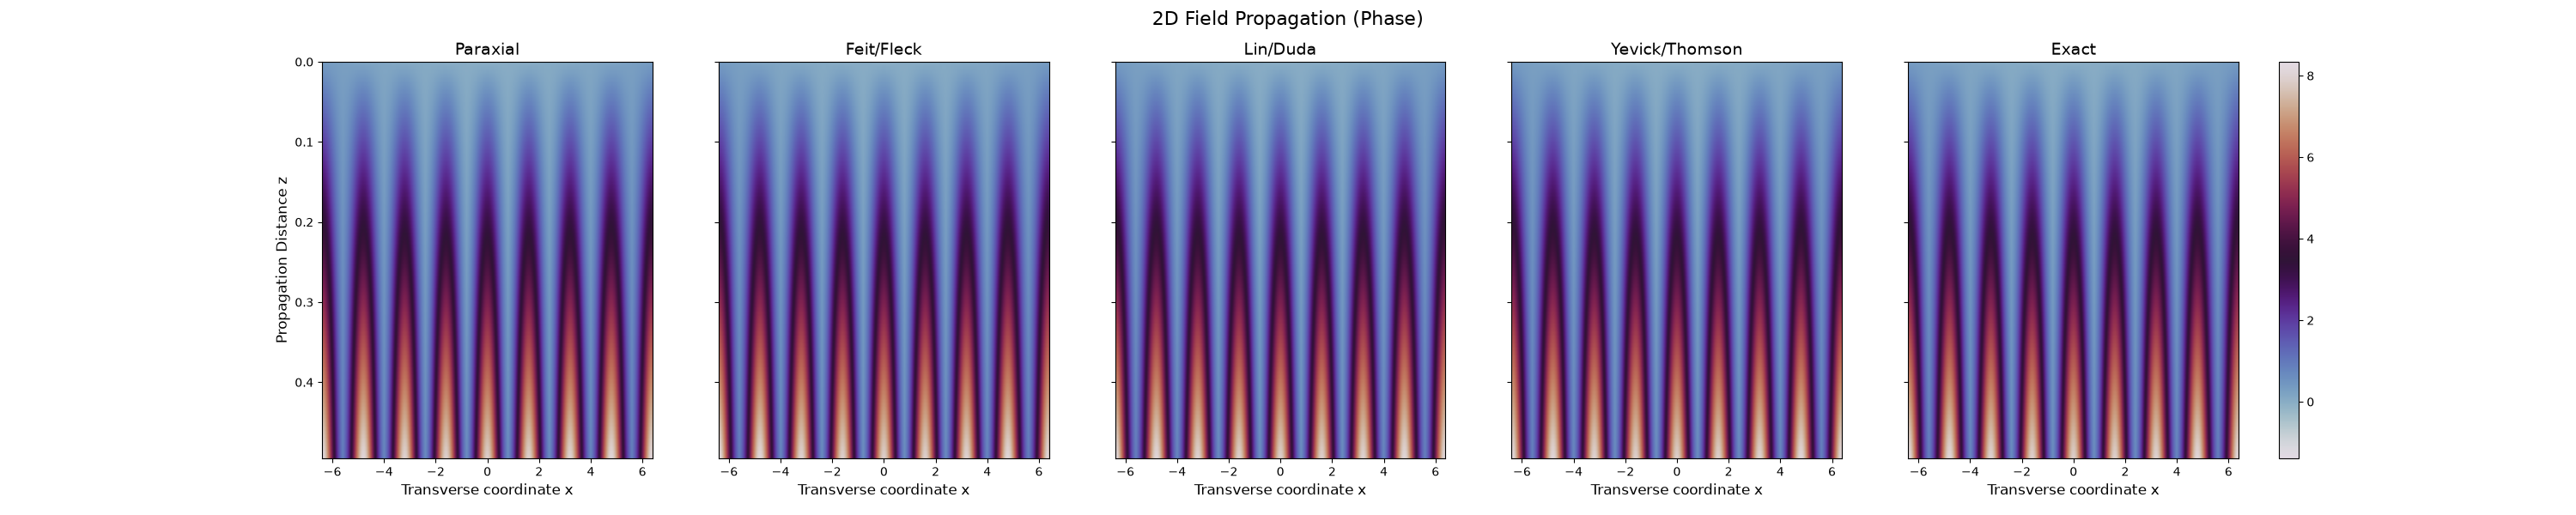

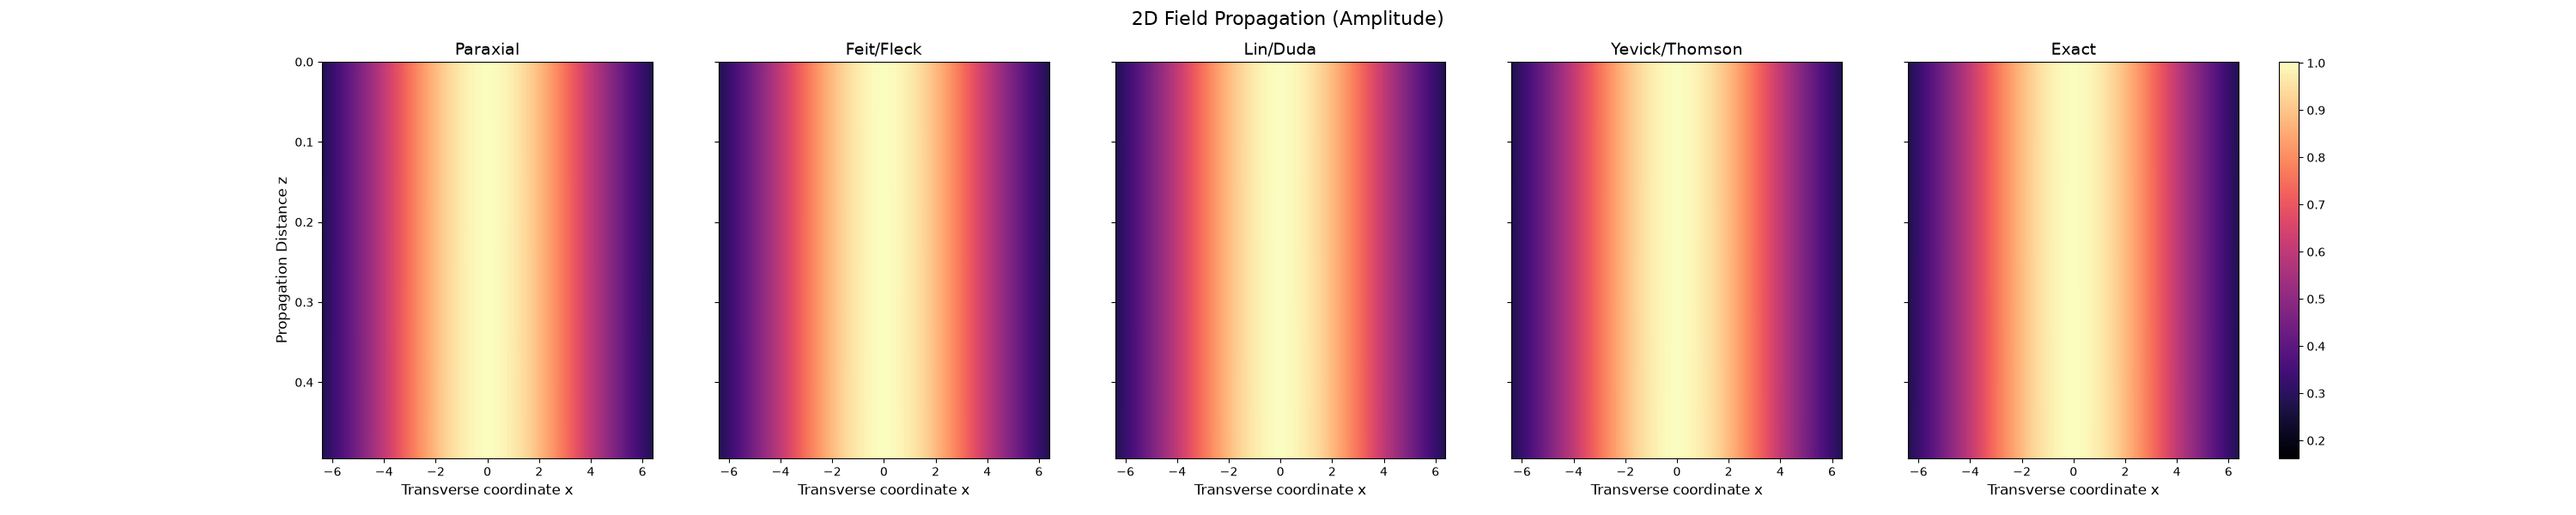

In [71]:
result.plot_wavefields()

## Plot Wavefield Propagation Through the Sample (only at the center of the grid $x=0$)

Plots two figures showing the evolution of the wavefields phase and amplitude along the propagation direction at the center of the grid.

(<Figure size 1000x800 with 3 Axes>,
 {'x_slider': <matplotlib.widgets.Slider at 0x327728c00>})

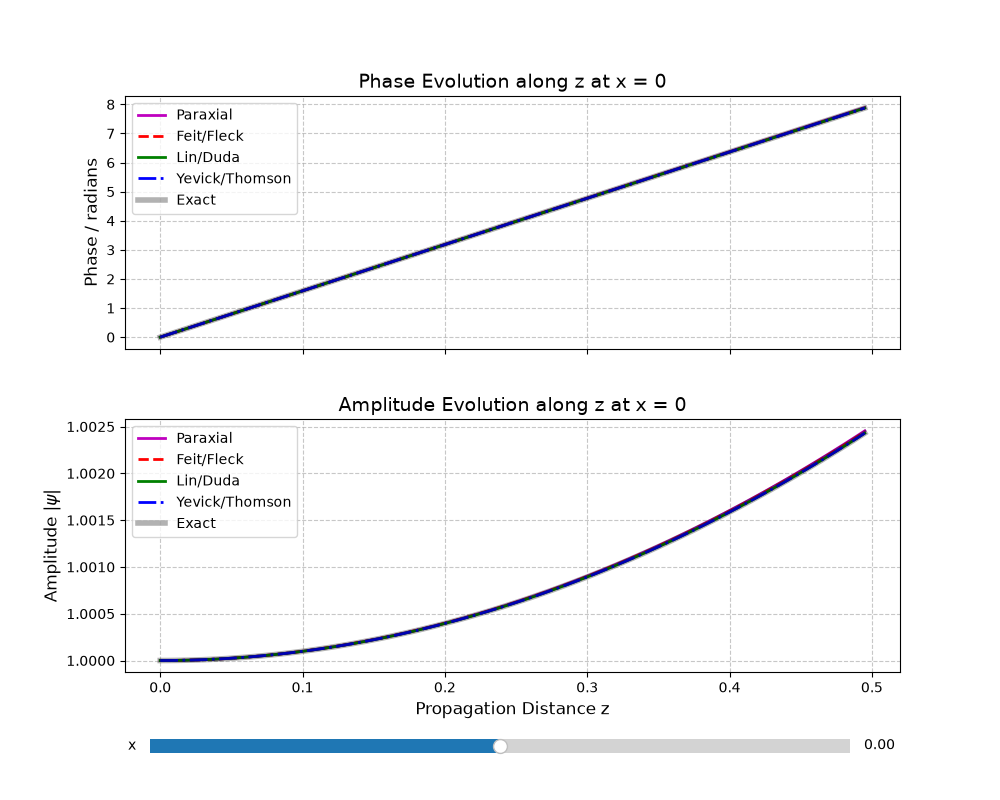

In [72]:
%matplotlib widget
result.plot_evolution_slider()

What do you notice about how the different approximations operators compare to the exact (grey line) solution?

## Plot Farfield Errors

In [73]:
print(list(result.wavefield_history.keys()))

['ParaxialOperator', 'FeitFleckOperator', 'LinDudaOperator', 'YevickThomsonOperator', 'ExactOperator']


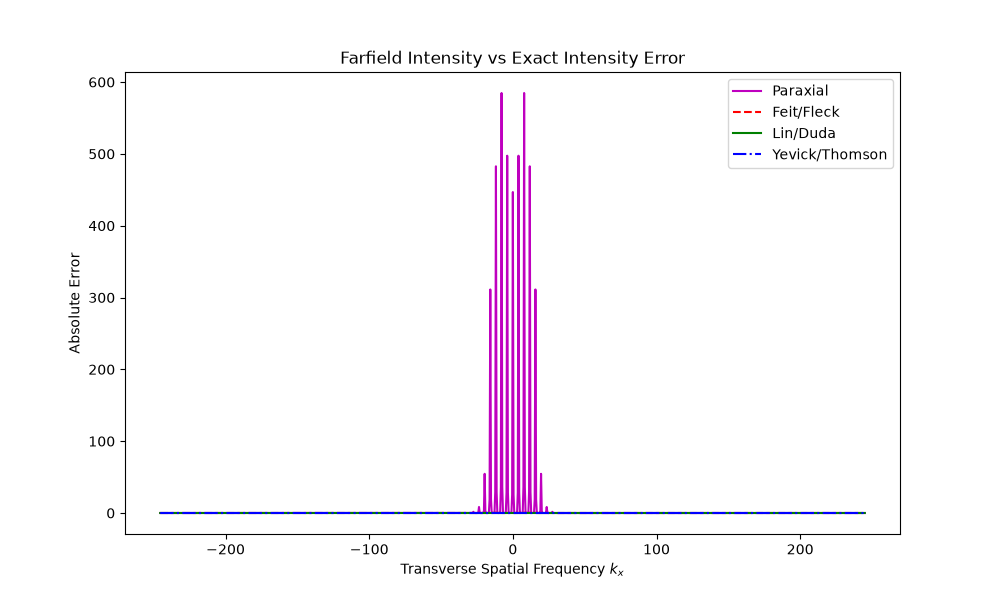

In [74]:
fig = result.plot_farfield_error(
    mode="intensity",
    operators=[
        "ParaxialOperator",
        "FeitFleckOperator",
        "LinDudaOperator",
        "YevickThomsonOperator",
    ],
)

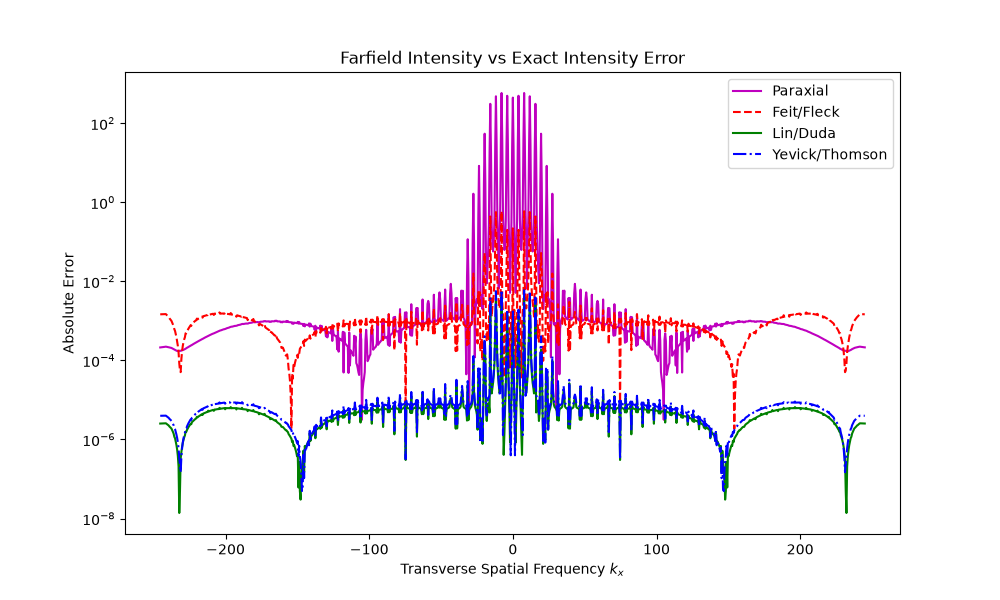

In [75]:
fig = result.plot_farfield_error(
    log_scale=True,
    mode="intensity",
    operators=[
        "ParaxialOperator",
        "FeitFleckOperator",
        "LinDudaOperator",
        "YevickThomsonOperator",
    ],
)

## Exercise Questions

Please type up your findings using markdown in your contributor notes folder either `contributor_notes/lizard_notes/` or `contributor_notes/L_notes/`.

1. Set the beam divergence angle to 0 degrees. What do you notice in the 2D wavefield plots as you increase the modulus of the sample?

```python
grid = SimulationGrid(divergence_angle=0.0) # Set to 0 degrees
sample = Apoferritin(modulus=0.5) # vary the modulus to see how the wavefield changes
```
2. Set the sample modulus to 0.0. 
    - What do you notice in the 2D wavefield plots as you increase the divergence angle of the beam?
    - What happens to the root mean square error (RMSE) for each operator as you increase the divergence angle?

```python
grid = SimulationGrid(divergence_angle=20.0) # vary the divergence angle to see how the wavefield changes
sample = Apoferritin(modulus=0.0)
```

3. Repeat the above using a different sample, such as `StraightWaveguides`, `ZigWaveguides`, `StraightBalls`, or `ZigBalls`. 
You will need to import them at the top of the notebook, e.g. `from ptychobench.samples import StraightWaveguides`. And then redefine the sample above, e.g. `sample = StraightWaveguides(modulus=5.0)`.
    - Do different samples give different results?
    - How do the errors compare for different samples?

### Extension Questions
4. In [samples guide](docs/samples_guide.md), you can find a list of parameters to change the structure of each sample and their default values. 

For example, you can change the period and core width of the `StraightWaveguides` sample by passing `period` and `core_width` parameters, e.g. `sample = StraightWaveguides(modulus=5.0, period=1.0, core_width=0.5)`.
 - How do these parameters affect the wavefield propagation and errors?